In [1]:
# Plot the Relative Risk for ozone with uncertainty

In [2]:
import os
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
from utils.utils import autosize_figure

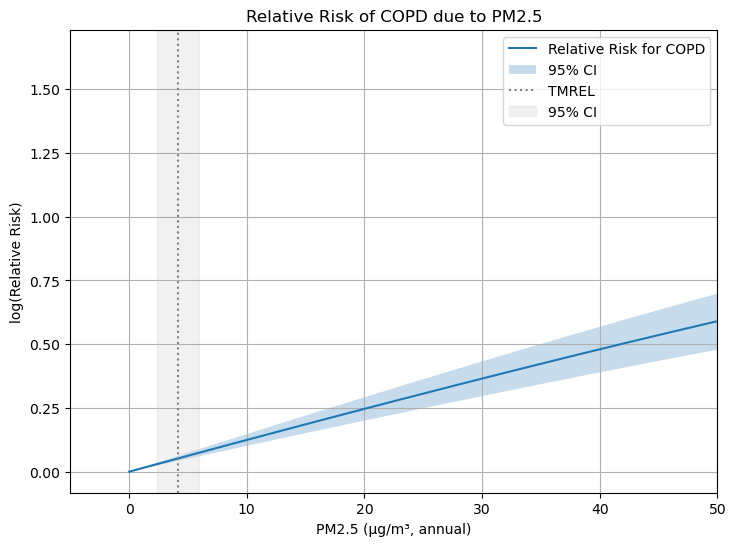

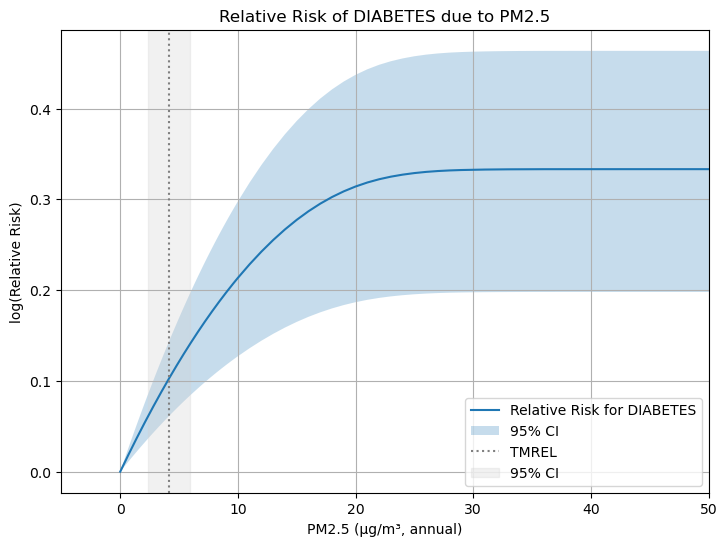

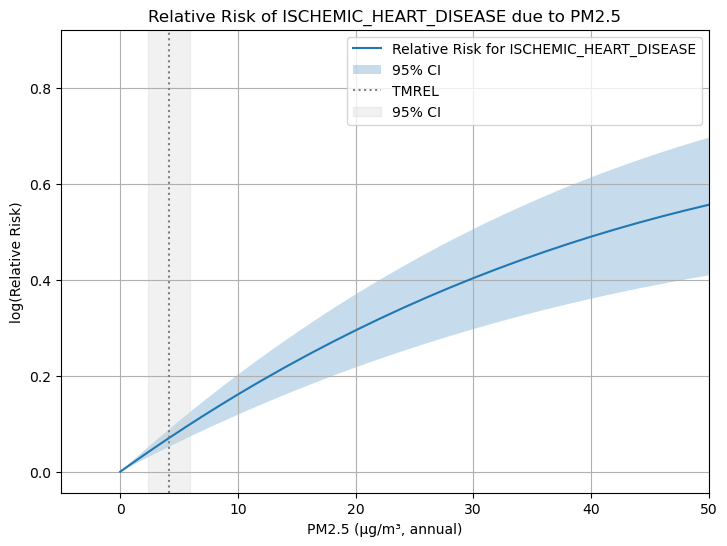

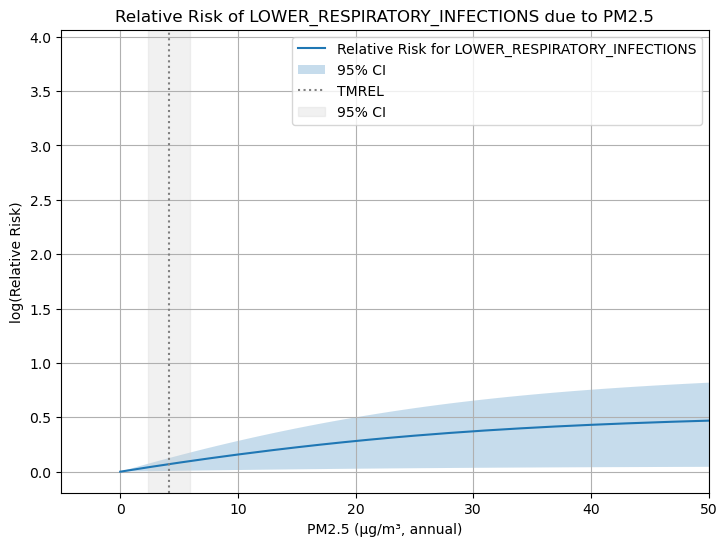

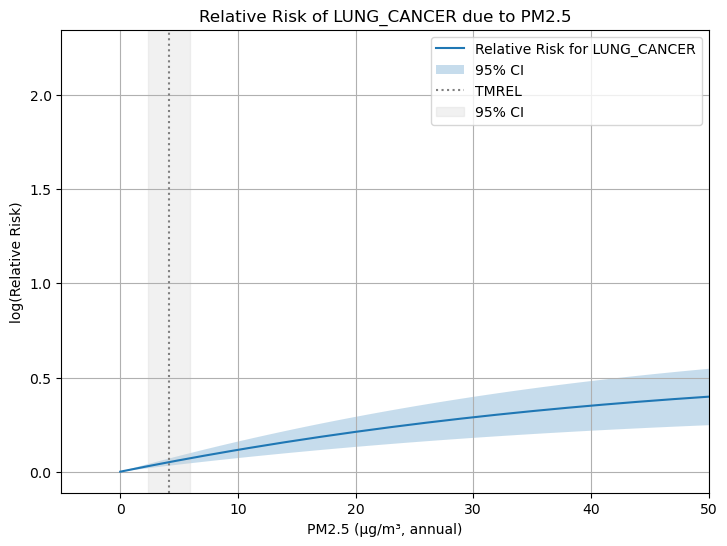

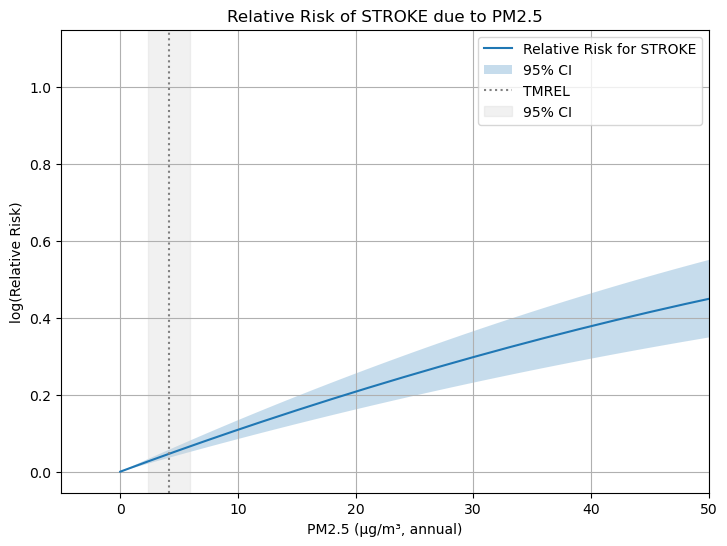

In [23]:
RR_DIR = "/glade/work/awells/air_quality/GBD21/RR_curves/"
SAVE_DIR = "/glade/u/home/awells/air_quality_project/plotting/mortality/pm25/"

health_vars = ["COPD", "DIABETES", "ISCHEMIC_HEART_DISEASE",
               "LOWER_RESPIRATORY_INFECTIONS", "LUNG_CANCER", "STROKE"]

threshold = 4.15  # µg/m³ [2.4-5.9 UI]

for health_VAR in health_vars:
    RR_file = f"IHME_GBD_2021_AIR_POLLUTION_1990_2021_PM_RR_{health_VAR}.nc"
    RR_path = os.path.join(RR_DIR, RR_file)
    RR_list = xr.open_dataset(RR_path)

    RR_mean = RR_list["mean"]  # mean
    RR_lower = RR_list["lower"]  # lower bound
    RR_upper = RR_list["upper"]  # upper bound

    # Plot
    fig, ax = plt.subplots(figsize=autosize_figure(1, 1))
    ax.plot(RR_list.exposure, np.log(RR_mean.data), label=f"Relative Risk for {health_VAR}")
    ax.fill_between(RR_list.exposure, np.log(RR_lower.data), np.log(RR_upper.data), alpha=0.25, label="95% CI")

    # Threshold lines
    ax.axvline(threshold, color="grey", linestyle=":", label="TMREL")
    ax.axvspan(threshold-1.75, threshold+1.75, color="lightgrey", alpha=0.3, label="95% CI")

    plt.xlim(-5, 50)
    plt.grid(True)

    # Labels and title
    ax.set_xlabel("PM2.5 (µg/m³, annual)")
    ax.set_ylabel("log(Relative Risk)")
    ax.set_title(f"Relative Risk of {health_VAR} due to PM2.5")
    ax.legend()

    out_file = f"log_RR_{health_VAR}.png"
    out_path = os.path.join(SAVE_DIR, out_file)
    plt.savefig(out_path)

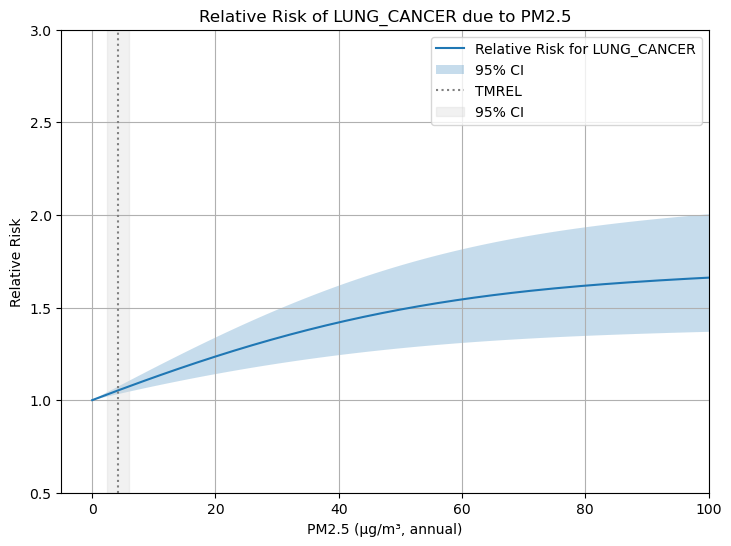

In [33]:
RR_DIR = "/glade/work/awells/air_quality/GBD21/RR_curves/"
SAVE_DIR = "/glade/u/home/awells/air_quality_project/plotting/mortality/pm25/"

health_vars = ["COPD", "DIABETES", "ISCHEMIC_HEART_DISEASE",
               "LOWER_RESPIRATORY_INFECTIONS", "LUNG_CANCER", "STROKE"]

threshold = 4.15  # µg/m³ [2.4-5.9 UI]

for health_VAR in ["LUNG_CANCER"]:
    RR_file = f"IHME_GBD_2021_AIR_POLLUTION_1990_2021_PM_RR_{health_VAR}.nc"
    RR_path = os.path.join(RR_DIR, RR_file)
    RR_list = xr.open_dataset(RR_path)

    RR_mean = RR_list["mean"]  # mean
    RR_lower = RR_list["lower"]  # lower bound
    RR_upper = RR_list["upper"]  # upper bound

    # Plot
    fig, ax = plt.subplots(figsize=autosize_figure(1, 1))
    ax.plot(RR_list.exposure, RR_mean.data, label=f"Relative Risk for {health_VAR}")
    ax.fill_between(RR_list.exposure, RR_lower.data, RR_upper.data, alpha=0.25, label="95% CI")

    # Threshold lines
    ax.axvline(threshold, color="grey", linestyle=":", label="TMREL")
    ax.axvspan(threshold-1.75, threshold+1.75, color="lightgrey", alpha=0.3, label="95% CI")

    plt.xlim(-5, 100)
    plt.ylim(0.5, 3)
    plt.grid(True)

    # Labels and title
    ax.set_xlabel("PM2.5 (µg/m³, annual)")
    ax.set_ylabel("Relative Risk")
    ax.set_title(f"Relative Risk of {health_VAR} due to PM2.5")
    ax.legend()

    out_file = f"RR_{health_VAR}.png"
    out_path = os.path.join(SAVE_DIR, out_file)
    plt.savefig(out_path)